In [21]:
import pandas as pd

train = pd.read_csv("/content/train_aWnotuB.csv")
test = pd.read_csv("/content/datasets_8494_11879_test_BdBKkAj.csv")

print(train.head())
print(test.head())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
              DateTime  Junction           ID
0  2017-07-01 00:00:00         1  20170701001
1  2017-07-01 01:00:00         1  20170701011
2  2017-07-01 02:00:00         1  20170701021
3  2017-07-01 03:00:00         1  20170701031
4  2017-07-01 04:00:00         1  20170701041


In [22]:
import pandas as pd

train = pd.read_csv("train_aWnotuB.csv")
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [23]:
print(train.shape)
print(train.columns)
train.info()

(48120, 4)
Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [24]:
train.head(10)

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


In [31]:
train['DateTime'] = pd.to_datetime(train['DateTime'])

In [33]:
train['Year'] = train['DateTime'].dt.year
train['Month'] = train['DateTime'].dt.month
train['Day'] = train['DateTime'].dt.day
train['Hour'] = train['DateTime'].dt.hour

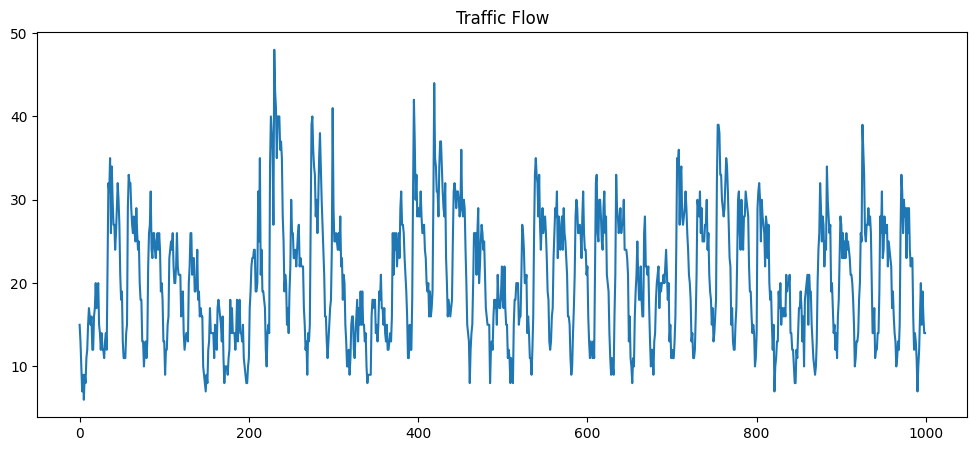

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train['Vehicles'][:1000])
plt.title("Traffic Flow")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = train[['Year','Month','Day','Hour','Junction']]
y = train['Vehicles']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [37]:
pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 2.8633354114713216


In [39]:
import joblib

joblib.dump(model, "traffic_model.pkl")

['traffic_model.pkl']

In [40]:
train.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0
Year,0
Month,0
Day,0
Hour,0


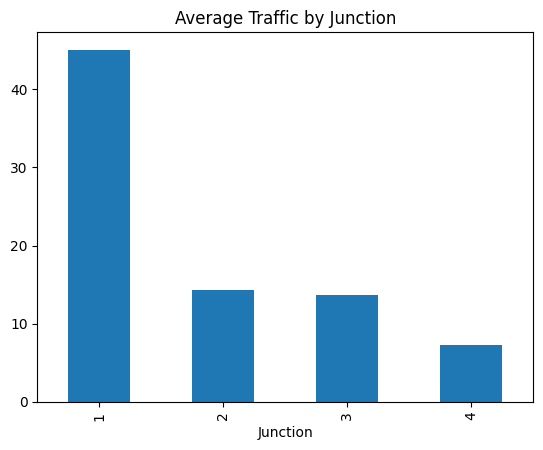

In [41]:
import matplotlib.pyplot as plt

train.groupby('Junction')['Vehicles'].mean().plot(kind='bar')

plt.title("Average Traffic by Junction")
plt.show()

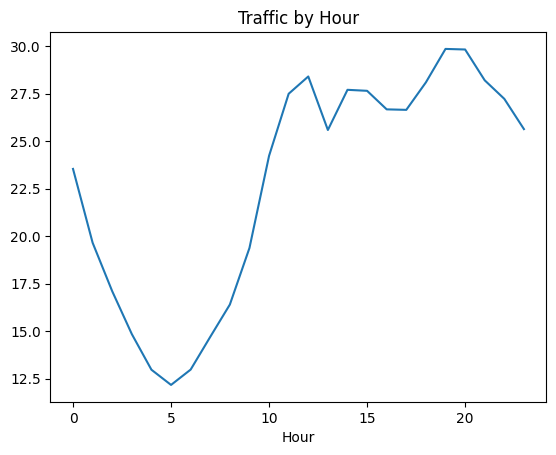

In [42]:
train.groupby('Hour')['Vehicles'].mean().plot()

plt.title("Traffic by Hour")
plt.show()

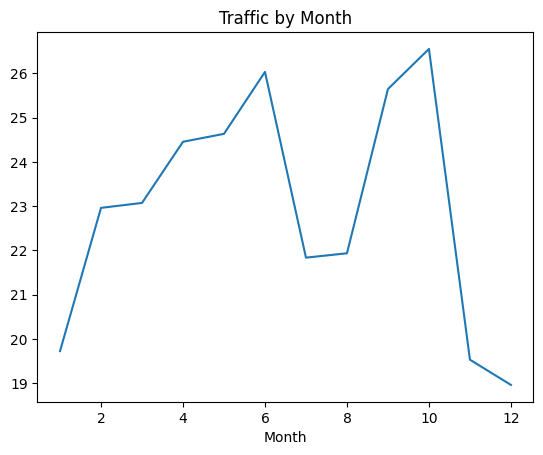

In [43]:
train.groupby('Month')['Vehicles'].mean().plot()

plt.title("Traffic by Month")
plt.show()

In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error

mae_lr = mean_absolute_error(y_test,pred_lr)

print(mae_lr)

9.751852286469317


In [47]:
mae_rf = mean_absolute_error(y_test,pred)

print("Random Forest:",mae_rf)
print("Linear Regression:",mae_lr)

Random Forest: 2.8633354114713216
Linear Regression: 9.751852286469317


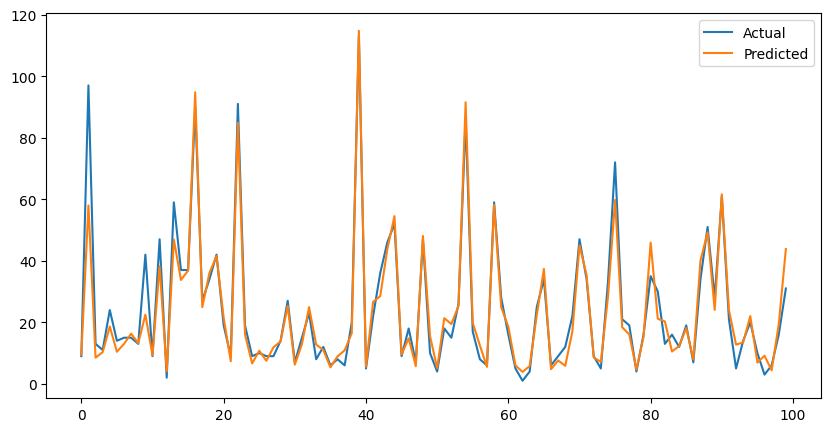

In [48]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100],label="Actual")

plt.plot(pred[:100],label="Predicted")

plt.legend()

plt.show()

In [50]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

results.head()

,Actual,Predicted
24632,9,9.51
36428,97,57.98
42150,13,8.52
23885,11,10.30
2174,24,18.64


In [52]:
results.to_csv("traffic_predictions.csv",index=False)